In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [3]:
import zipfile
with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('.')
print("Extraction done!")

Extraction done!


In [5]:
import pandas as pd
df = pd.read_csv('creditcard.csv')
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [10]:
print(df['Class'].value_counts())
print("\nFraud percentage:", round(df['Class'].value_counts()[1] / len(df) * 100, 3), "%")

Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.173 %


In [12]:
import matplotlib.pyplot as plt

fraud = df[df['Class'] == 1]
genuine = df[df['Class'] == 0]

print("Fraud transactions - Amount stats:")
print(fraud['Amount'].describe())

print("\nGenuine transactions - Amount stats:")
print(genuine['Amount'].describe())

Fraud transactions - Amount stats:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

Genuine transactions - Amount stats:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Amount কলাম স্কেল করা
scaler = StandardScaler()
df['scaled_amount'] = scaler.fit_transform(df[['Amount']])
df = df.drop(['Amount', 'Time'], axis=1)

# ফিচার এবং টার্গেট আলাদা করা
X = df.drop('Class', axis=1)
y = df['Class']

# ট্রেন-টেস্ট স্প্লিট
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain fraud ratio:", round(y_train.mean()*100, 3), "%")
print("Test fraud ratio:", round(y_test.mean()*100, 3), "%")

KeyError: "None of [Index(['Amount'], dtype='object')] are in the [columns]"

In [22]:
!pip install imbalanced-learn -q

In [24]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())

Before SMOTE: {0: 227451, 1: 394}
After SMOTE: {0: 227451, 1: 227451}


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# মডেল ট্রেন করা (SMOTE করা ডেটা দিয়ে)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_smote, y_train_smote)

# টেস্ট ডেটায় প্রেডিকশন (আসল ইমব্যালেন্সড টেস্ট ডেটায়)
y_pred = lr_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[55355  1509]
 [    8    90]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962



In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_smote, y_train_smote)

y_pred_rf = rf_model.predict(X_test)

print("Confusion Matrix (Random Forest):")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))

Confusion Matrix (Random Forest):
[[56852    12]
 [   17    81]]

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [30]:
!pip install xgboost -q

In [32]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)
xgb_model.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb_model.predict(X_test)

print("Confusion Matrix (XGBoost):")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb))

Confusion Matrix (XGBoost):
[[56826    38]
 [   14    84]]

Classification Report (XGBoost):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.69      0.86      0.76        98

    accuracy                           1.00     56962
   macro avg       0.84      0.93      0.88     56962
weighted avg       1.00      1.00      1.00     56962



In [35]:
!pip install shap  -q

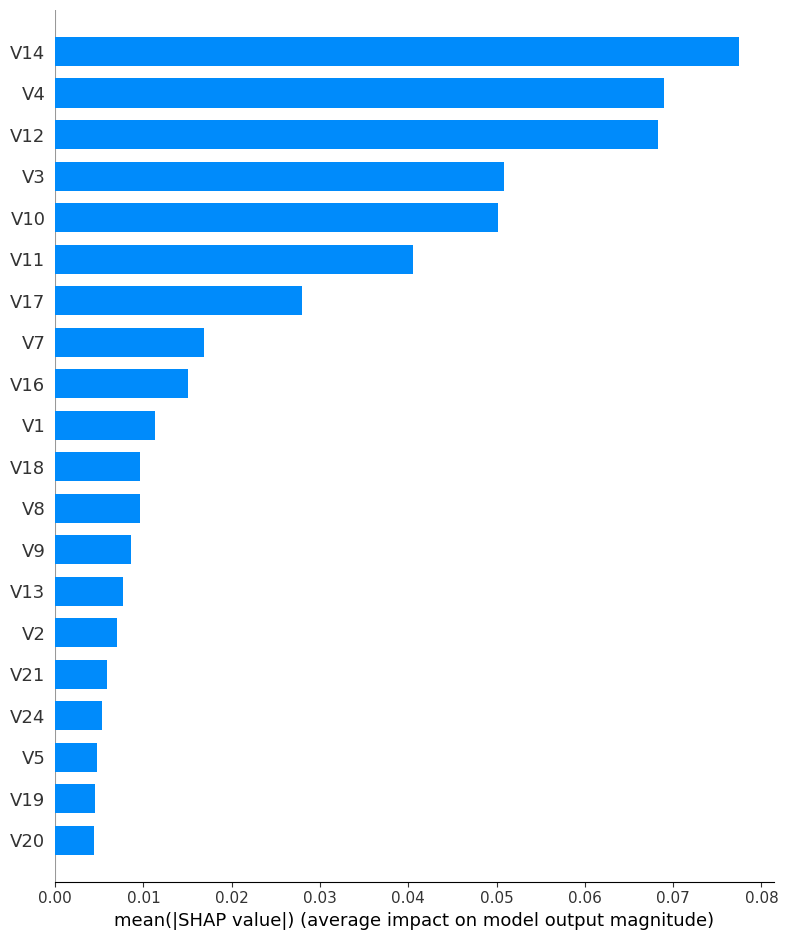

In [37]:
import shap

# একটা ছোট sample নেওয়া হচ্ছে দ্রুত হিসাবের জন্য
X_sample = X_test.sample(100, random_state=42)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values[:,:,1], X_sample, plot_type="bar")

In [39]:
import joblib

joblib.dump(rf_model, 'fraud_model.pkl')
joblib.dump(scaler, 'amount_scaler.pkl')

print("Model saved successfully!")

Model saved successfully!


In [40]:
from google.colab import files
files.download('fraud_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>